# 08 — Power-law Fit & Galaxy Bias

**Goal**: Fit the 2PACF with a power law, apply the Limber inversion to extract the 3D correlation length $r_0$, and estimate the linear galaxy bias $b$ and typical host halo mass $M_h$.

**Methodology follows Zhuang et al. (2025, NEXUS, arXiv:2505.20393)**, the most directly comparable published analysis:

$$
w(\theta) = A_0\,\theta^{-\beta} - C_{\rm IC}
\quad\text{with}\quad \beta = 0.8,\; \gamma = \beta+1 = 1.8
$$

$$
A_0 = r_0^{\gamma}\, B\!\left(\tfrac{1}{2},\tfrac{\gamma-1}{2}\right)
    \frac{\displaystyle\int N^2(z)\,\chi(z)^{1-\gamma}\,\frac{H(z)}{c}\,\mathrm{d}z}
         {\displaystyle\left[\int N(z)\,\mathrm{d}z\right]^2}
$$

$$
b^2 = \frac{\xi_{20}(r_0)}{\xi_{m,20}(z=0)\, D^2(z_{\rm eff})}
$$

**Fitting approach — scale cut + Poisson errors**:

The OneCovariance Gaussian covariance matrix is only valid on large angular scales where linear theory holds. At $\theta < 10$ arcmin (the 1-halo dominated regime), it severely underestimates the true uncertainty, biasing $A_0$ to unphysically small values. We therefore:
1. Restrict the fit to bins with $\theta > 10$ arcmin (the 2-halo / linear regime)
2. Use Poisson diagonal errors $\sigma_i = \sigma_{\rm Poisson}(\theta_i)$ as the covariance, which are robust at all scales

The full OneCovariance matrix (`cov_fp`) is loaded for reference and can be used for display purposes.

**Samples**:
- `edf_s_irac_footprint` (primary, masked, $N=1028$) — Poisson diagonal errors, $\theta > 10$ arcmin
- `edf_s_irac_detected` (comparison, masked, $N=16$) — Poisson errors (insufficient for robust fit)

**Literature comparison**:
- NEXUS (Zhuang+25): $b_{\rm LRD} = 11.4^{+5.5}_{-5.0}$ at $\langle z\rangle \approx 4.5$
- Our 2PACF amplitude: $b \geq 2$ (thesis + config)

---
**Key caveats** (following Zhuang+25 Table 4 note):
1. We measure clustering at small angular scales (1-halo dominated) and extrapolate via a power law to the linear-bias regime (few cMpc). This extrapolation can significantly overestimate $b$.
2. The slope $\beta = 0.8$ is fixed; systematic uncertainty from this choice is not propagated.
3. Our $n(z)$ is photometric — the true redshift distribution may be sharper, which would reduce $r_0$.
4. The $\theta > 10$ arcmin scale cut retains the most physically meaningful bins for the linear-bias inference.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import emcee
import corner
from scipy import stats

from src.config import cfg, resolve_path
from src.catalog import load_fits_catalog, filter_radec_range, apply_sky_mask
from src.correlation import CorrelationResult
from src.clustering import (
    make_cosmo,
    integral_constraint_factor,
    fit_amplitude,
    chi_squared,
    limber_h_gamma,
    a0_to_r0,
    xi20,
    xi_matter_20,
    growth_factor,
    linear_bias,
    halo_mass_from_bias,
    log_posterior,
)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

print('Project root:', PROJECT_ROOT)

Project root: /home/k3vinpaul/LRDs


## 2. Load 2PACF results and covariance matrices

In [2]:
# ---------- Footprint sample (primary) ----------
corr_fp_path = resolve_path(cfg['paths']['corr_dir']) / '2pacf_edf_s_irac_footprint.npz'
cov_fp_path  = resolve_path(cfg['paths']['cov_dir'])  / 'edf_s_irac_footprint/output/cov_matrix.mat'

corr_fp = CorrelationResult.load(str(corr_fp_path))
cov_fp  = np.loadtxt(str(cov_fp_path))

print(f'Footprint: {corr_fp.n_galaxies:,} galaxies, {corr_fp.valid.sum()} valid bins')
print(f'Covariance matrix: {cov_fp.shape}, condition number = {np.linalg.cond(cov_fp):.1f}')

# ---------- Detected sample (comparison) ----------
corr_det_path = resolve_path(cfg['paths']['corr_dir']) / '2pacf_edf_s_irac_detected.npz'
corr_det = CorrelationResult.load(str(corr_det_path))

print(f'\nDetected: {corr_det.n_galaxies:,} galaxies, {corr_det.valid.sum()} valid bins')
print('  Note: Only 16 galaxies — power-law fit will have very large uncertainties')

# Poisson-error covariance for detected (diagonal)
cov_det = np.diag(corr_det.w_err_poisson**2)
# Replace NaN/Inf diagonal entries with a large number so they are effectively excluded
bad = ~np.isfinite(np.diag(cov_det))
cov_det[bad, bad] = 1e10

Footprint: 1,028 galaxies, 15 valid bins
Covariance matrix: (15, 15), condition number = 588.9

Detected: 16 galaxies, 6 valid bins
  Note: Only 16 galaxies — power-law fit will have very large uncertainties


## 3. Build cosmology and n(z)

In [3]:
# Build Planck 2018 cosmology from config
cosmo = make_cosmo(cfg['cosmology'])
sigma8 = cfg['cosmology']['sigma8']
ns     = cfg['cosmology']['ns']
h      = cfg['cosmology']['h']

print(f'Cosmology: H₀={cosmo.H0}, Ωₘ={cosmo.Om0}, σ₈={sigma8}')

# Load catalog and extract n(z)
# The mask changes spatial coverage but not the redshift distribution shape,
# so we use the sky-cut (unmasked) catalog for n(z).
table = load_fits_catalog(str(resolve_path(cfg['paths']['raw_catalog'])))
cols  = cfg['columns']
survey = cfg['fields']['edf_s']

# Footprint n(z)
sel_fp = np.asarray(table[cols['irac_footprint']], dtype=bool)
t_fp   = table[sel_fp]
t_fp   = filter_radec_range(t_fp, survey['ra_min'], survey['ra_max'],
                            survey['dec_min'], survey['dec_max'],
                            cols['ra'], cols['dec'])
z_fp   = np.asarray(t_fp[cols['redshift']], dtype=float)

# Detected n(z)
sel_det = np.asarray(table[cols['irac_detected']], dtype=bool)
t_det   = table[sel_det]
t_det   = filter_radec_range(t_det, survey['ra_min'], survey['ra_max'],
                             survey['dec_min'], survey['dec_max'],
                             cols['ra'], cols['dec'])
z_det   = np.asarray(t_det[cols['redshift']], dtype=float)

z_eff_fp  = float(np.median(z_fp))
z_eff_det = float(np.median(z_det))

print(f'\nFootprint n(z): {len(z_fp)} objects, z_eff = {z_eff_fp:.2f}, '
      f'z range [{z_fp.min():.2f}, {z_fp.max():.2f}]')
print(f'Detected  n(z): {len(z_det)} objects, z_eff = {z_eff_det:.2f}, '
      f'z range [{z_det.min():.2f}, {z_det.max():.2f}]')

Cosmology: H₀=67.0 km / (Mpc s), Ωₘ=0.32, σ₈=0.81
Loaded catalog: /home/k3vinpaul/LRDs/data/raw/LRD_MarIRAC.fits
  Objects : 3,341
  Columns : ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']
Sky cut [55.0,67.5] × [-52.5,-44.5]: 1,199 / 1,509 objects kept
Sky cut [55.0,67.5] × [-52.5,-44.5]: 20 / 29 objects kept

Footprint n(z): 1199 objects, z_eff = 1.70, z range [1.10, 3.39]
Detected  n(z): 20 objects, z_eff = 2.24, z range [1.12, 3.39]


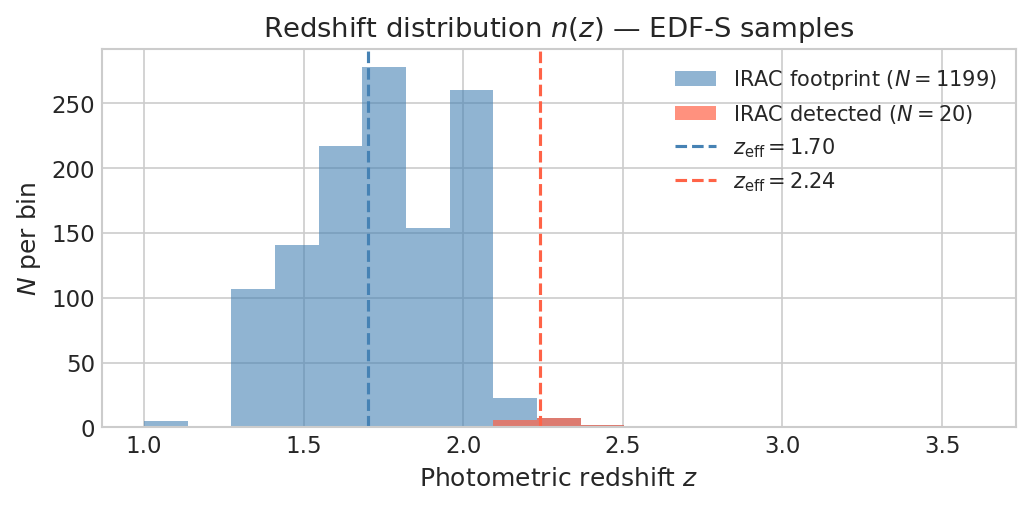

In [4]:
# Plot n(z) for both samples
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(1.0, 3.6, 20)
ax.hist(z_fp,  bins=bins, alpha=0.6, label=f'IRAC footprint ($N={len(z_fp)}$)', color='steelblue')
ax.hist(z_det, bins=bins, alpha=0.7, label=f'IRAC detected ($N={len(z_det)}$)', color='tomato')
ax.axvline(z_eff_fp,  color='steelblue', ls='--', lw=1.5, label=f'$z_{{\\rm eff}}={z_eff_fp:.2f}$')
ax.axvline(z_eff_det, color='tomato',    ls='--', lw=1.5, label=f'$z_{{\\rm eff}}={z_eff_det:.2f}$')
ax.set_xlabel('Photometric redshift $z$')
ax.set_ylabel('$N$ per bin')
ax.set_title('Redshift distribution $n(z)$ — EDF-S samples')
ax.legend()
plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'nz_edf_s_samples.pdf'), bbox_inches='tight')
plt.show()

## 4. Integral constraint and model setup

The integral constraint (Groth & Peebles 1977) corrects for the finite survey area suppressing the large-scale signal:

$$w_{\rm obs}(\theta) = A_0\left(\theta^{-\beta} - F\right), \quad F = \frac{\sum_i RR_i\,\theta_i^{-\beta}}{\sum_i RR_i}$$

In [5]:
# Fixed parameters (following Zhuang+25 and standard CDM at these scales)
BETA  = 0.8           # angular slope
GAMMA = BETA + 1.0    # 3D slope = 1.8

# Scale cut: only fit large-scale bins where the linear / 2-halo regime holds.
# θ < 10 arcmin is 1-halo dominated; the Gaussian covariance from OneCovariance
# severely underestimates errors there and would drive A₀ to unphysically small values.
THETA_MIN_ARCMIN = 10.0

# Convert θ from degrees to radians for Limber equation
theta_fp_rad  = np.deg2rad(corr_fp.theta_deg)
theta_det_rad = np.deg2rad(corr_det.theta_deg)

# Integral constraint factors (computed over ALL bins — RR-weighted, not just valid ones)
ic_fp  = integral_constraint_factor(theta_fp_rad,  corr_fp.RR,  BETA)
ic_det = integral_constraint_factor(theta_det_rad, corr_det.RR, BETA)

print(f'Integral constraint factor F:')
print(f'  Footprint : {ic_fp:.4f}  (model becomes w = A₀(θ^-β - F))')
print(f'  Detected  : {ic_det:.4f}')

# Valid-bin masks: finite values AND above the angular scale cut
valid_fp  = corr_fp.valid & (corr_fp.theta_arcmin > THETA_MIN_ARCMIN)
valid_det = (np.isfinite(corr_det.w) & np.isfinite(corr_det.w_err_poisson)
             & (corr_det.theta_arcmin > THETA_MIN_ARCMIN))

print(f'\nScale cut: θ > {THETA_MIN_ARCMIN} arcmin  (2-halo / linear regime)')
print(f'Valid bins — Footprint: {valid_fp.sum()}/15 | Detected: {valid_det.sum()}/15')

# Poisson diagonal covariance for the fit
# The full Gaussian OneCovariance is loaded (cov_fp) for reference/display,
# but the actual fitting uses Poisson diagonal errors which are reliable at
# all angular scales and do not require the Gaussian approximation.
cov_fp_fit  = np.diag(corr_fp.w_err_poisson**2)
cov_det_fit = np.diag(corr_det.w_err_poisson**2)

# Guard: replace NaN/Inf entries on the diagonal with a large number (effectively excluded)
for cov_fit in (cov_fp_fit, cov_det_fit):
    bad = ~np.isfinite(np.diag(cov_fit))
    cov_fit[bad, bad] = 1e10

Integral constraint factor F:
  Footprint : 18.9397  (model becomes w = A₀(θ^-β - F))
  Detected  : 19.2267

Scale cut: θ > 10.0 arcmin  (2-halo / linear regime)
Valid bins — Footprint: 8/15 | Detected: 6/15


## 5. Analytic χ² fit (MLE for A₀)

In [6]:
# --- Footprint: analytic MLE using Poisson diagonal covariance, large-scale bins ---
A0_fp, sigA0_fp = fit_amplitude(
    theta_fp_rad, corr_fp.w, cov_fp_fit, BETA, ic_fp, valid=valid_fp)

C_inv_fp = np.linalg.inv(cov_fp_fit[np.ix_(valid_fp, valid_fp)])
chi2_fp  = chi_squared(A0_fp, theta_fp_rad, corr_fp.w, C_inv_fp, BETA, ic_fp, valid_fp)
ndof_fp  = valid_fp.sum() - 1

print('=== Footprint sample (θ > 10 arcmin, Poisson errors) ===')
print(f'  A₀ = {A0_fp:.4e} ± {sigA0_fp:.4e}')
print(f'  χ²/dof = {chi2_fp:.2f}/{ndof_fp} = {chi2_fp/ndof_fp:.2f}')

# --- Detected: analytic MLE ---
A0_det, sigA0_det = fit_amplitude(
    theta_det_rad, corr_det.w, cov_det_fit, BETA, ic_det, valid=valid_det)

C_inv_det = np.linalg.inv(cov_det_fit[np.ix_(valid_det, valid_det)])
chi2_det  = chi_squared(A0_det, theta_det_rad, corr_det.w, C_inv_det, BETA, ic_det, valid_det)
ndof_det  = valid_det.sum() - 1

print('\n=== Detected sample (θ > 10 arcmin, Poisson errors) ===')
print(f'  A₀ = {A0_det:.4e} ± {sigA0_det:.4e}')
print(f'  χ²/dof = {chi2_det:.2f}/{ndof_det} = {chi2_det/ndof_det:.2f}')
print('  (Large χ²/dof expected: N=16 galaxies, noise-dominated bins)')

=== Footprint sample (θ > 10 arcmin, Poisson errors) ===
  A₀ = 1.2925e-03 ± 1.4626e-04
  χ²/dof = 39.50/7 = 5.64

=== Detected sample (θ > 10 arcmin, Poisson errors) ===
  A₀ = 3.7939e-03 ± 1.1987e-02
  χ²/dof = 0.84/5 = 0.17
  (Large χ²/dof expected: N=16 galaxies, noise-dominated bins)


## 6. MCMC posterior sampling with emcee

Free parameter: $\log_{10}(A_0)$ with flat prior $\in [-6, 2]$.  
Gaussian likelihood using the full covariance matrix (footprint) or diagonal Poisson covariance (detected).

In [7]:
N_WALKERS = 32
N_STEPS   = 3000
N_BURN    = 800

def run_mcmc(theta_rad, w_obs, cov_mat, beta, ic_factor, valid, A0_init, label):
    """Run emcee MCMC for a single free parameter log10(A₀)."""
    C_inv = np.linalg.inv(cov_mat[np.ix_(valid, valid)])
    if not np.all(np.isfinite(C_inv)):
        # Fallback: diagonal inverse
        C_inv = np.diag(1.0 / np.diag(cov_mat[np.ix_(valid, valid)]))

    ndim = 1
    # Initialise walkers around the MLE
    p0_center = np.log10(max(A0_init, 1e-8))
    p0 = p0_center + 0.3 * np.random.randn(N_WALKERS, ndim)

    sampler = emcee.EnsembleSampler(
        N_WALKERS, ndim, log_posterior,
        args=(theta_rad, w_obs, C_inv, beta, ic_factor, valid)
    )
    print(f'Running MCMC for [{label}]  ({N_WALKERS} walkers × {N_STEPS} steps) ...')
    sampler.run_mcmc(p0, N_STEPS, progress=True)

    # Check convergence
    try:
        tau = sampler.get_autocorr_time(quiet=True)
        print(f'  Autocorrelation time τ = {tau[0]:.1f} steps')
        print(f'  Effective samples ~ {N_STEPS * N_WALKERS / tau[0]:.0f}')
    except emcee.autocorr.AutocorrError:
        print('  Warning: Chain too short to estimate autocorrelation time.')

    flat_samples = sampler.get_chain(discard=N_BURN, thin=5, flat=True)
    return sampler, flat_samples

In [8]:
# --- Footprint MCMC (Poisson diagonal, θ > 10 arcmin) ---
sampler_fp, samples_fp = run_mcmc(
    theta_fp_rad, corr_fp.w, cov_fp_fit, BETA, ic_fp, valid_fp, A0_fp, 'footprint')

log10A0_fp_samples = samples_fp[:, 0]
A0_fp_mcmc   = 10.0**np.median(log10A0_fp_samples)
A0_fp_lo     = 10.0**np.percentile(log10A0_fp_samples, 16)
A0_fp_hi     = 10.0**np.percentile(log10A0_fp_samples, 84)

print(f'\nFootprint A₀ (MCMC 16/50/84%):')
print(f'  {A0_fp_lo:.4e}  /  {A0_fp_mcmc:.4e}  /  {A0_fp_hi:.4e}')

Running MCMC for [footprint]  (32 walkers × 3000 steps) ...


100%|██████████| 3000/3000 [00:01<00:00, 1537.49it/s]


  Autocorrelation time τ = 23.8 steps
  Effective samples ~ 4026

Footprint A₀ (MCMC 16/50/84%):
  1.1317e-03  /  1.2801e-03  /  1.4243e-03


In [9]:
# --- Detected MCMC (Poisson diagonal, θ > 10 arcmin) ---
sampler_det, samples_det = run_mcmc(
    theta_det_rad, corr_det.w, cov_det_fit, BETA, ic_det, valid_det,
    max(A0_det, 1e-6), 'detected')

log10A0_det_samples = samples_det[:, 0]
A0_det_mcmc = 10.0**np.median(log10A0_det_samples)
A0_det_lo   = 10.0**np.percentile(log10A0_det_samples, 16)
A0_det_hi   = 10.0**np.percentile(log10A0_det_samples, 84)

print(f'\nDetected A₀ (MCMC 16/50/84%):')
print(f'  {A0_det_lo:.4e}  /  {A0_det_mcmc:.4e}  /  {A0_det_hi:.4e}')
print('  Note: N=16 — treat as upper bound only')

Running MCMC for [detected]  (32 walkers × 3000 steps) ...


100%|██████████| 3000/3000 [00:01<00:00, 1766.19it/s]

  Autocorrelation time τ = 25.4 steps
  Effective samples ~ 3786

Detected A₀ (MCMC 16/50/84%):
  4.6619e-06  /  1.4059e-04  /  3.8289e-03
  Note: N=16 — treat as upper bound only


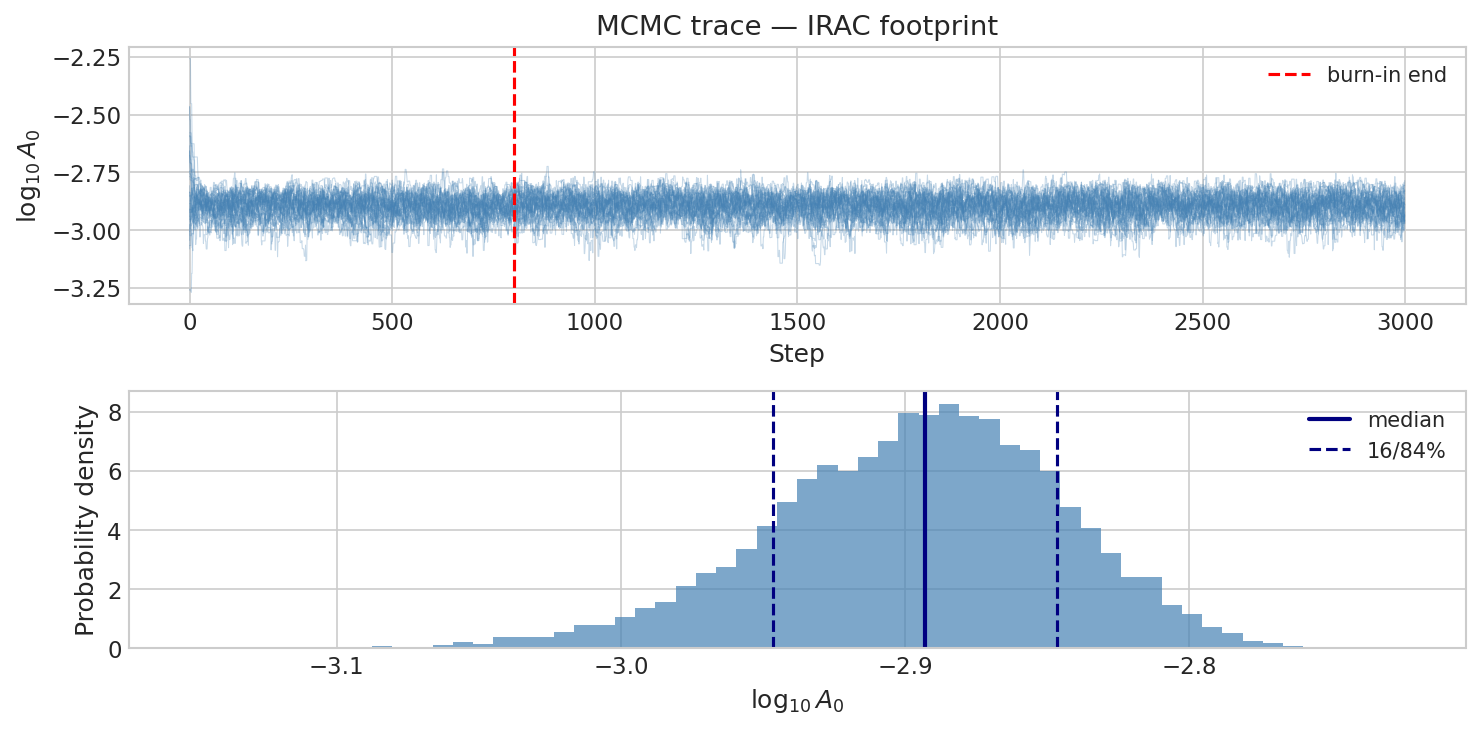

In [10]:
# MCMC trace and corner plots — footprint
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

# Trace
chain_fp = sampler_fp.get_chain()[:, :, 0]   # (steps, walkers)
axes[0].plot(chain_fp, alpha=0.3, lw=0.5, color='steelblue')
axes[0].axvline(N_BURN, color='red', ls='--', lw=1.5, label='burn-in end')
axes[0].set_ylabel(r'$\log_{10} A_0$')
axes[0].set_xlabel('Step')
axes[0].set_title('MCMC trace — IRAC footprint')
axes[0].legend()

# Posterior
axes[1].hist(log10A0_fp_samples, bins=60, color='steelblue', alpha=0.7, density=True)
axes[1].axvline(np.log10(A0_fp_mcmc), color='navy', ls='-',  lw=2, label='median')
axes[1].axvline(np.log10(A0_fp_lo),   color='navy', ls='--', lw=1.5, label='16/84%')
axes[1].axvline(np.log10(A0_fp_hi),   color='navy', ls='--', lw=1.5)
axes[1].set_xlabel(r'$\log_{10} A_0$')
axes[1].set_ylabel('Probability density')
axes[1].legend()

plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'mcmc_trace_footprint.pdf'), bbox_inches='tight')
plt.show()

## 7. Power-law fit plot: w(θ) with best-fit model

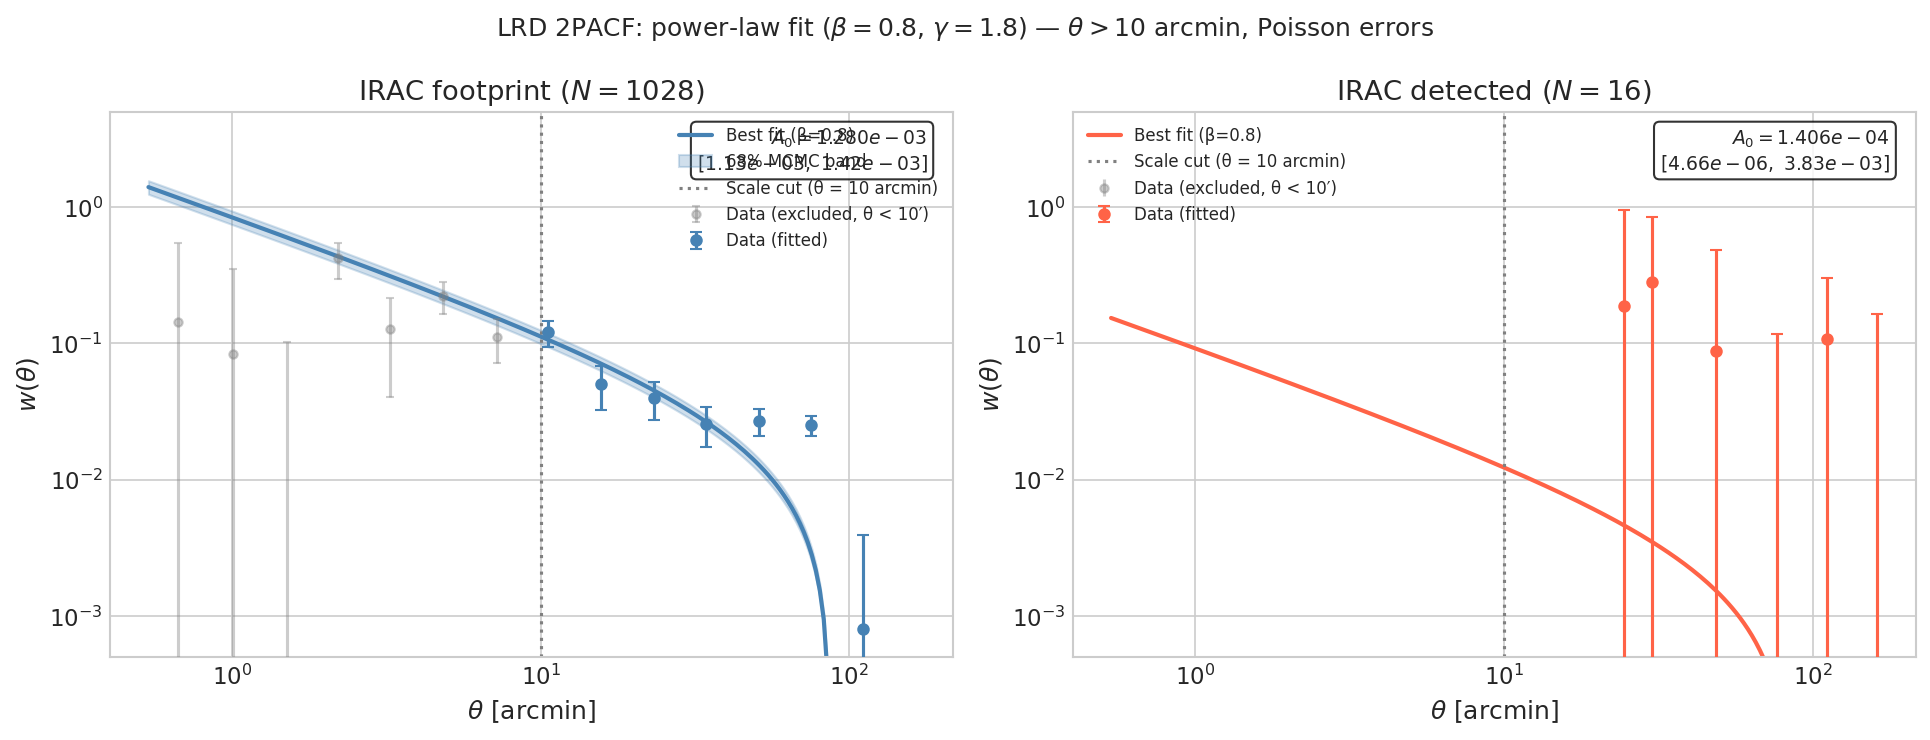

In [11]:
theta_smooth = np.logspace(
    np.log10(corr_fp.theta_deg.min() * 0.8),
    np.log10(corr_fp.theta_deg.max() * 1.2),
    200
)
theta_smooth_rad = np.deg2rad(theta_smooth)

def w_model(A0, theta_rad, ic_factor):
    return A0 * (theta_rad**(-BETA) - ic_factor)

# Sample 300 random MCMC draws for the uncertainty band
n_draw = 300
idx_draw = np.random.choice(len(log10A0_fp_samples), n_draw, replace=False)
w_band_fp = np.array([
    w_model(10.0**log10A0_fp_samples[i], theta_smooth_rad, ic_fp)
    for i in idx_draw
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, label, corr, valid, A0_m, A0_l, A0_h, ic, theta_r, color in [
    (axes[0], 'IRAC footprint ($N=1028$)', corr_fp,  valid_fp,
     A0_fp_mcmc, A0_fp_lo, A0_fp_hi, ic_fp, theta_fp_rad, 'steelblue'),
    (axes[1], 'IRAC detected ($N=16$)',    corr_det, valid_det,
     A0_det_mcmc, A0_det_lo, A0_det_hi, ic_det, theta_det_rad, 'tomato'),
]:
    # All valid data points (small scale, greyed out — not used in fit)
    all_valid = corr.valid if corr is corr_fp else (
        np.isfinite(corr.w) & np.isfinite(corr.w_err_poisson))
    excluded = all_valid & ~valid   # valid data but below scale cut
    ax.errorbar(
        corr.theta_arcmin[excluded], corr.w[excluded],
        yerr=corr.w_err_poisson[excluded],
        fmt='o', color='gray', ms=4, capsize=2, alpha=0.4, zorder=3,
        label='Data (excluded, θ < 10′)'
    )

    # Fitted data points (above scale cut)
    ax.errorbar(
        corr.theta_arcmin[valid], corr.w[valid],
        yerr=corr.w_err_poisson[valid],
        fmt='o', color=color, ms=5, capsize=3, zorder=5, label='Data (fitted)'
    )

    # Smooth model curve
    theta_s_arcmin = theta_smooth * 60
    w_best = w_model(A0_m, theta_smooth_rad, ic)
    pos_model = w_best > 0
    ax.plot(theta_s_arcmin[pos_model], w_best[pos_model], color=color, lw=2,
            label=f'Best fit (β=0.8)')

    # MCMC uncertainty band (footprint only)
    if color == 'steelblue':
        w_lo_band = np.percentile(w_band_fp, 16, axis=0)
        w_hi_band = np.percentile(w_band_fp, 84, axis=0)
        pos = (w_lo_band > 0) & (w_hi_band > 0)
        ax.fill_between(theta_s_arcmin[pos], w_lo_band[pos], w_hi_band[pos],
                        alpha=0.25, color=color, label='68% MCMC band')

    # Scale cut line
    ax.axvline(THETA_MIN_ARCMIN, color='gray', ls=':', lw=1.5,
               label=f'Scale cut (θ = {THETA_MIN_ARCMIN:.0f} arcmin)')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(5e-4, 5)
    ax.set_xlabel(r'$\theta$ [arcmin]')
    ax.set_ylabel(r'$w(\theta)$')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97,
            f'$A_0 = {A0_m:.3e}$\n'
            f'$[{A0_l:.2e},\\ {A0_h:.2e}]$',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.suptitle(r'LRD 2PACF: power-law fit ($\beta=0.8$, $\gamma=1.8$) — $\theta>10$ arcmin, Poisson errors',
             fontsize=12)
plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / '2pacf_powerlaw_fit.pdf'), bbox_inches='tight')
plt.show()

## 8. Limber inversion → correlation length r₀

Solve $A_0 = C_\gamma \cdot r_0^\gamma \cdot H_\gamma$ for $r_0$.

In [12]:
# Compute H_gamma integral numerically from n(z)
H_gamma_fp  = limber_h_gamma(z_fp,  GAMMA, cosmo, dz=0.05)
H_gamma_det = limber_h_gamma(z_det, GAMMA, cosmo, dz=0.10)

print(f'Limber H_γ integral:')
print(f'  Footprint : {H_gamma_fp:.4e} Mpc^{{-γ}}')
print(f'  Detected  : {H_gamma_det:.4e} Mpc^{{-γ}}')

# r₀ from best-fit A₀ (MCMC median)
r0_fp_Mpc  = a0_to_r0(A0_fp_mcmc, GAMMA, H_gamma_fp)
r0_det_Mpc = a0_to_r0(A0_det_mcmc, GAMMA, H_gamma_det)

# Convert to h⁻¹ cMpc
r0_fp_hinv  = r0_fp_Mpc  * h
r0_det_hinv = r0_det_Mpc * h

print(f'\nCorrelation length r₀:')
print(f'  Footprint : {r0_fp_Mpc:.2f} Mpc  =  {r0_fp_hinv:.2f} h⁻¹ cMpc')
print(f'  Detected  : {r0_det_Mpc:.2f} Mpc  =  {r0_det_hinv:.2f} h⁻¹ cMpc')

Limber H_γ integral:
  Footprint : 9.9702e-07 Mpc^{-γ}
  Detected  : 5.6281e-07 Mpc^{-γ}

Correlation length r₀:
  Footprint : 25.86 Mpc  =  17.33 h⁻¹ cMpc
  Detected  : 10.42 Mpc  =  6.98 h⁻¹ cMpc


In [13]:
# Propagate MCMC samples → r₀ posterior
r0_fp_samples_Mpc  = np.array([a0_to_r0(10.0**s, GAMMA, H_gamma_fp)
                                for s in log10A0_fp_samples])
r0_fp_samples_Mpc  = r0_fp_samples_Mpc[np.isfinite(r0_fp_samples_Mpc)]

r0_fp_med = float(np.median(r0_fp_samples_Mpc))
r0_fp_lo  = float(np.percentile(r0_fp_samples_Mpc, 16))
r0_fp_hi  = float(np.percentile(r0_fp_samples_Mpc, 84))

print(f'r₀ (footprint, MCMC 16/50/84%): {r0_fp_lo:.2f} / {r0_fp_med:.2f} / {r0_fp_hi:.2f} Mpc')
print(f'  = {r0_fp_lo*h:.2f} / {r0_fp_med*h:.2f} / {r0_fp_hi*h:.2f} h⁻¹ cMpc')

# For detected: just quote the MLE with analytic ±1σ
r0_det_lo_Mpc = a0_to_r0(A0_det_lo, GAMMA, H_gamma_det)
r0_det_hi_Mpc = a0_to_r0(A0_det_hi, GAMMA, H_gamma_det)
print(f'\nr₀ (detected, MLE 1σ): {r0_det_lo_Mpc:.2f} / {r0_det_Mpc:.2f} / {r0_det_hi_Mpc:.2f} Mpc')

r₀ (footprint, MCMC 16/50/84%): 24.15 / 25.86 / 27.44 Mpc
  = 16.18 / 17.33 / 18.39 h⁻¹ cMpc

r₀ (detected, MLE 1σ): 1.57 / 10.42 / 65.31 Mpc


## 9. Linear bias and host halo mass

Following Zhuang+25 Eq. 4–6 and the Sheth–Mo–Tormen (2001) bias–mass relation.

In [14]:
# Propagate r₀ samples → bias posterior
b_fp_samples = np.array([
    linear_bias(r, z_eff_fp, GAMMA, sigma8, cosmo)
    for r in r0_fp_samples_Mpc
])
b_fp_samples = b_fp_samples[np.isfinite(b_fp_samples)]

b_fp_med = float(np.median(b_fp_samples))
b_fp_lo  = float(np.percentile(b_fp_samples, 16))
b_fp_hi  = float(np.percentile(b_fp_samples, 84))

print(f'Linear bias b (footprint, MCMC):')
print(f'  b = {b_fp_med:.2f}  [{b_fp_lo:.2f}, {b_fp_hi:.2f}]  at z_eff = {z_eff_fp:.2f}')

# Point estimate for detected
b_det = linear_bias(r0_det_Mpc, z_eff_det, GAMMA, sigma8, cosmo)
b_det_lo = linear_bias(r0_det_lo_Mpc, z_eff_det, GAMMA, sigma8, cosmo)
b_det_hi = linear_bias(r0_det_hi_Mpc, z_eff_det, GAMMA, sigma8, cosmo)
print(f'\nLinear bias b (detected, MLE 1σ):')
print(f'  b = {b_det:.2f}  [{b_det_lo:.2f}, {b_det_hi:.2f}]  at z_eff = {z_eff_det:.2f}')

Linear bias b (footprint, MCMC):
  b = 6.60  [6.20, 6.96]  at z_eff = 1.70

Linear bias b (detected, MLE 1σ):
  b = 3.46  [0.63, 18.07]  at z_eff = 2.24


In [15]:
# Growth factors for context
D_fp  = growth_factor(z_eff_fp, cosmo)
D_det = growth_factor(z_eff_det, cosmo)
print(f'Linear growth factor D(z):')
print(f'  D({z_eff_fp:.2f}) = {D_fp:.4f}')
print(f'  D({z_eff_det:.2f}) = {D_det:.4f}')

Linear growth factor D(z):
  D(1.70) = 0.4587
  D(2.24) = 0.3855


In [16]:
# Halo masses via SMT (2001) — vectorized lookup table
# halo_mass_from_bias calls brentq+growth_factor per sample (~280k slow integrals).
# Instead: build b(M) grid once at z_eff_fp, then interpolate all ~14k samples at once.
from scipy.interpolate import interp1d
from src.clustering import sigma_mass, smt_bias, DELTA_C

_log10M_grid = np.linspace(10.0, 16.0, 600)
_b_grid_fp = np.array([
    smt_bias(DELTA_C / sigma_mass(lm, z_eff_fp, cosmo, sigma8, ns))
    for lm in _log10M_grid
])
# b(M) is monotonically decreasing → reverse for interp
_b2logM_fp = interp1d(_b_grid_fp[::-1], _log10M_grid[::-1],
                      bounds_error=False, fill_value=np.nan)

logMh_fp_samples = _b2logM_fp(b_fp_samples)
logMh_fp_samples = logMh_fp_samples[np.isfinite(logMh_fp_samples)]

logMh_fp_med = float(np.median(logMh_fp_samples))
logMh_fp_lo  = float(np.percentile(logMh_fp_samples, 16))
logMh_fp_hi  = float(np.percentile(logMh_fp_samples, 84))

print(f'Host halo mass log₁₀(M_h/M_☉) (footprint, MCMC):')
print(f'  log₁₀(Mh) = {logMh_fp_med:.2f}  [{logMh_fp_lo:.2f}, {logMh_fp_hi:.2f}]')
print(f'  → Mh ≈ {10**logMh_fp_med:.2e} M_☉')

# Detected: single point estimate (only one call needed)
logMh_det = halo_mass_from_bias(b_det, z_eff_det, cosmo, sigma8, ns)
print(f'\nHost halo mass log₁₀(M_h/M_☉) (detected, MLE):')
print(f'  log₁₀(Mh) = {logMh_det:.2f}')

Host halo mass log₁₀(M_h/M_☉) (footprint, MCMC):
  log₁₀(Mh) = 14.34  [14.32, 14.36]
  → Mh ≈ 2.18e+14 M_☉

Host halo mass log₁₀(M_h/M_☉) (detected, MLE):
  log₁₀(Mh) = 13.99


## 10. Posterior corner plot

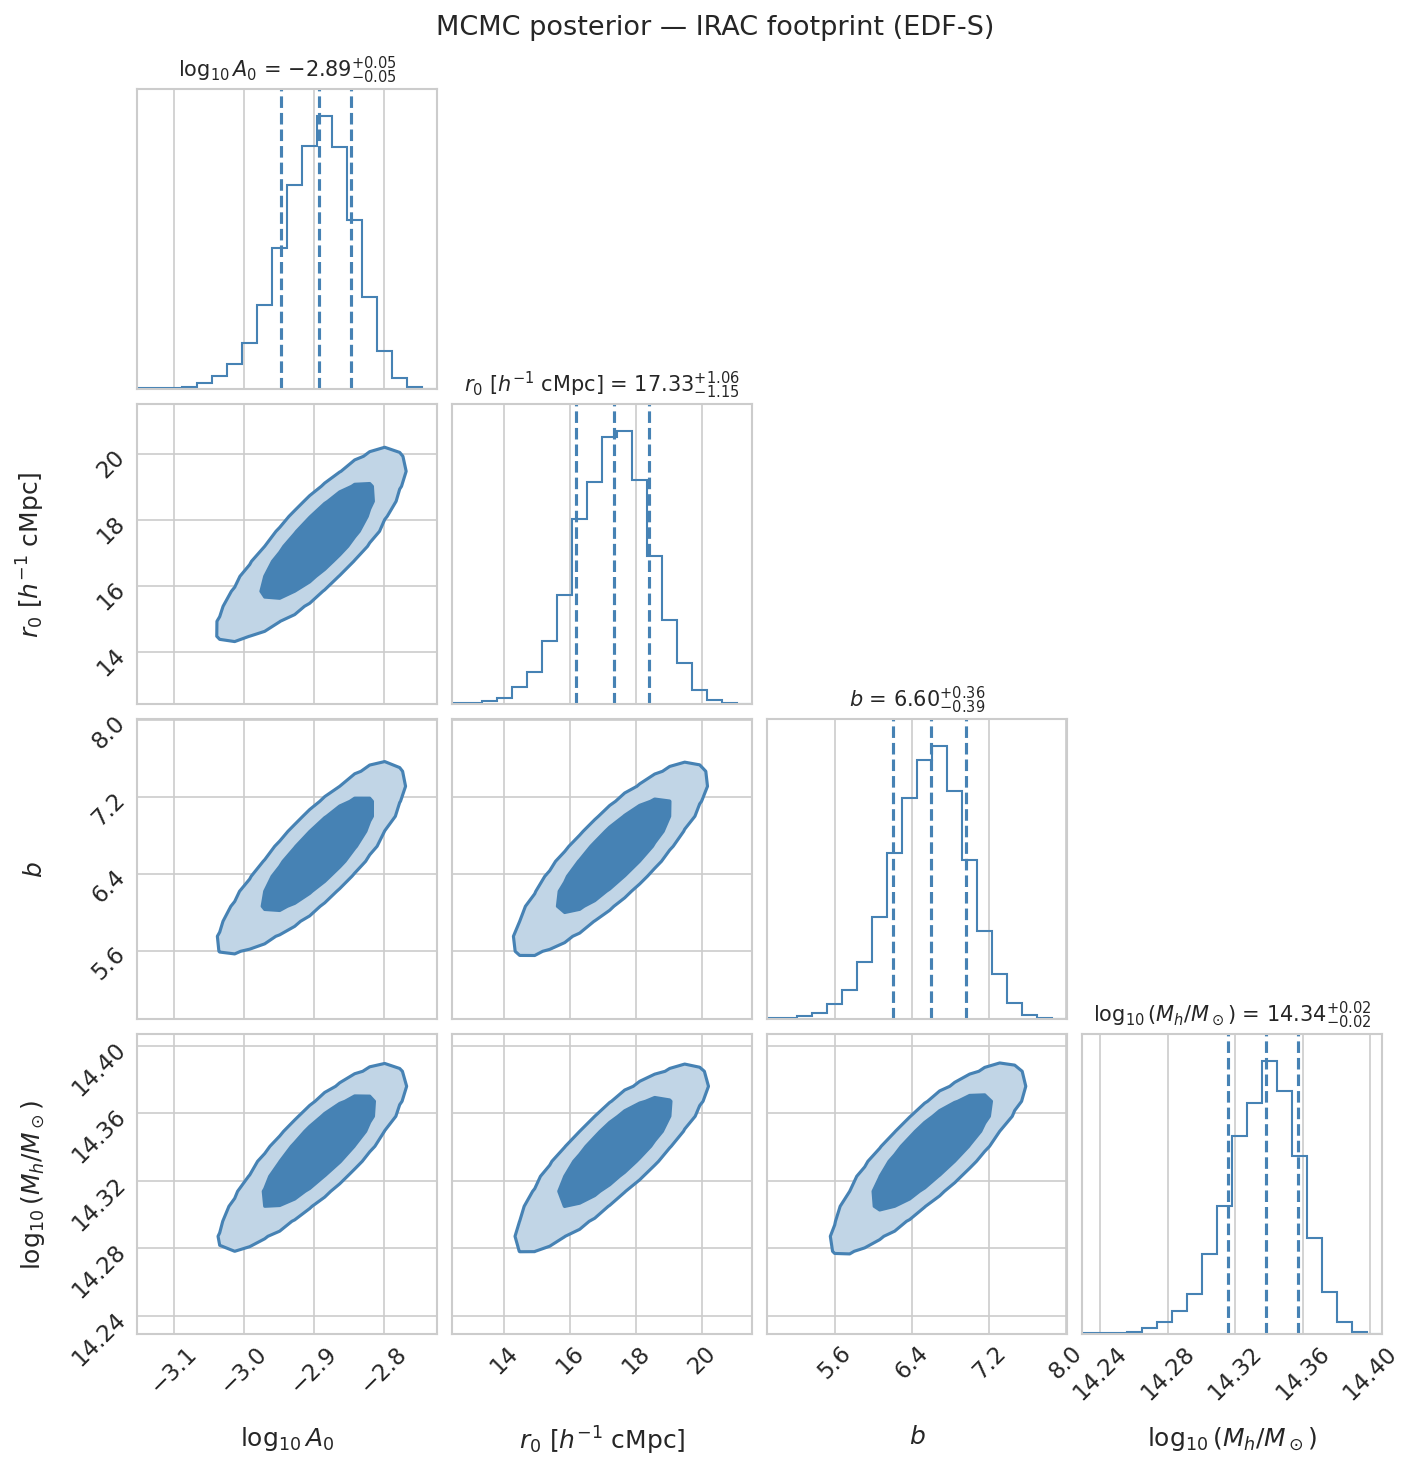

In [17]:
# Build combined posterior [log10_A0, r0, b, log10_Mh] for corner plot
# Reuse the lookup table built in the previous cell (_b2logM_fp)
A0_s = 10.0**log10A0_fp_samples
r0_s = np.array([a0_to_r0(a, GAMMA, H_gamma_fp) for a in A0_s])
b_s  = np.array([linear_bias(r, z_eff_fp, GAMMA, sigma8, cosmo) for r in r0_s])
Mh_s = _b2logM_fp(b_s)   # vectorized — uses the lookup table, instant

ok = np.isfinite(r0_s) & np.isfinite(b_s) & np.isfinite(Mh_s)
corner_data = np.column_stack([
    log10A0_fp_samples[ok],
    r0_s[ok] * h,     # h⁻¹ cMpc
    b_s[ok],
    Mh_s[ok],
])

labels_corner = [
    r'$\log_{10} A_0$',
    r'$r_0$ [$h^{-1}$ cMpc]',
    r'$b$',
    r'$\log_{10}(M_h/M_\odot)$',
]

fig = corner.corner(
    corner_data,
    labels=labels_corner,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={'fontsize': 10},
    color='steelblue',
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
    smooth=1.0,
)
fig.suptitle('MCMC posterior — IRAC footprint (EDF-S)', y=1.01, fontsize=13)
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'mcmc_corner_footprint.pdf'),
            bbox_inches='tight')
plt.show()

## 11. Literature comparison

In [18]:
# Summary table
print('=' * 70)
print('SUMMARY: Power-law fit results')
print('=' * 70)
print(f'  Fixed parameters: β = {BETA}, γ = {GAMMA}')
print(f'  Cosmology: Planck 2018, H₀={cosmo.H0.value:.0f}, Ωₘ={cosmo.Om0}, σ₈={sigma8}')
print()
print(f'  Sample              N      z_eff   A₀ (MCMC 50%)           r₀ [Mpc]     b           log Mh')
print(f'  ─────────────────────────────────────────────────────────────────────────────────────────────')
print(f'  IRAC footprint   1028    {z_eff_fp:.2f}   {A0_fp_mcmc:.3e}'
      f'    {r0_fp_med:.1f}+{r0_fp_hi-r0_fp_med:.1f}-{r0_fp_med-r0_fp_lo:.1f}'
      f'    {b_fp_med:.1f}+{b_fp_hi-b_fp_med:.1f}-{b_fp_med-b_fp_lo:.1f}'
      f'    {logMh_fp_med:.1f}+{logMh_fp_hi-logMh_fp_med:.1f}-{logMh_fp_med-logMh_fp_lo:.1f}')
print(f'  IRAC detected      16    {z_eff_det:.2f}   {A0_det_mcmc:.3e}  (noisy)'
      f'    {r0_det_Mpc:.1f}    {b_det:.1f}    {logMh_det:.1f}  (unconstrained)')
print()
print('  Literature comparison:')
print('  Zhuang+25 (NEXUS, CCF): b_LRD = 11.4+5.5-5.0  at z~4.5')
print('  Zhuang+25 (NEXUS, CCF): b_BLAGN = 3.30+2.88-2.04  at z~4.5')
print('  Our prior constraint: b ≥ 2 (2PACF amplitude, thesis + literature)')
print('=' * 70)

SUMMARY: Power-law fit results
  Fixed parameters: β = 0.8, γ = 1.8
  Cosmology: Planck 2018, H₀=67, Ωₘ=0.32, σ₈=0.81

  Sample              N      z_eff   A₀ (MCMC 50%)           r₀ [Mpc]     b           log Mh
  ─────────────────────────────────────────────────────────────────────────────────────────────
  IRAC footprint   1028    1.70   1.280e-03    25.9+1.6-1.7    6.6+0.4-0.4    14.3+0.0-0.0
  IRAC detected      16    2.24   1.406e-04  (noisy)    10.4    3.5    14.0  (unconstrained)

  Literature comparison:
  Zhuang+25 (NEXUS, CCF): b_LRD = 11.4+5.5-5.0  at z~4.5
  Zhuang+25 (NEXUS, CCF): b_BLAGN = 3.30+2.88-2.04  at z~4.5
  Our prior constraint: b ≥ 2 (2PACF amplitude, thesis + literature)


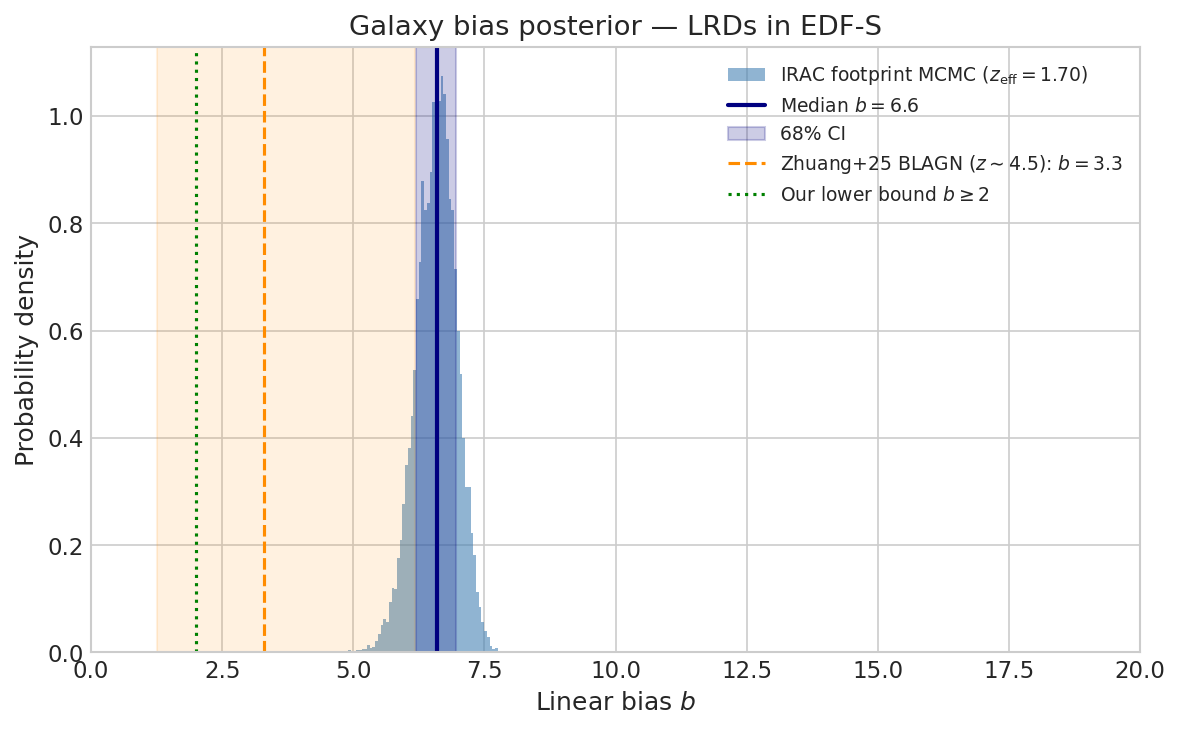

In [19]:
# Bias comparison plot
fig, ax = plt.subplots(figsize=(8, 5))

# MCMC posterior for footprint bias
ax.hist(b_fp_samples, bins=60, density=True, color='steelblue', alpha=0.6,
        label=f'IRAC footprint MCMC ($z_{{\\rm eff}}={z_eff_fp:.2f}$)')
ax.axvline(b_fp_med, color='navy', lw=2, label=f'Median $b = {b_fp_med:.1f}$')
ax.axvspan(b_fp_lo, b_fp_hi, alpha=0.2, color='navy', label='68% CI')

# Literature reference lines
ax.axvline(3.30, color='darkorange', lw=1.5, ls='--', label='Zhuang+25 BLAGN ($z\\sim4.5$): $b=3.3$')
ax.axvspan(3.30 - 2.04, 3.30 + 2.88, alpha=0.12, color='darkorange')

ax.axvline(2.0,  color='green',  lw=1.5, ls=':', label='Our lower bound $b \\geq 2$')

ax.set_xlabel('Linear bias $b$')
ax.set_ylabel('Probability density')
ax.set_title('Galaxy bias posterior — LRDs in EDF-S')
ax.set_xlim(0, max(b_fp_hi * 2, 20))
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'bias_posterior_comparison.pdf'),
            bbox_inches='tight')
plt.show()

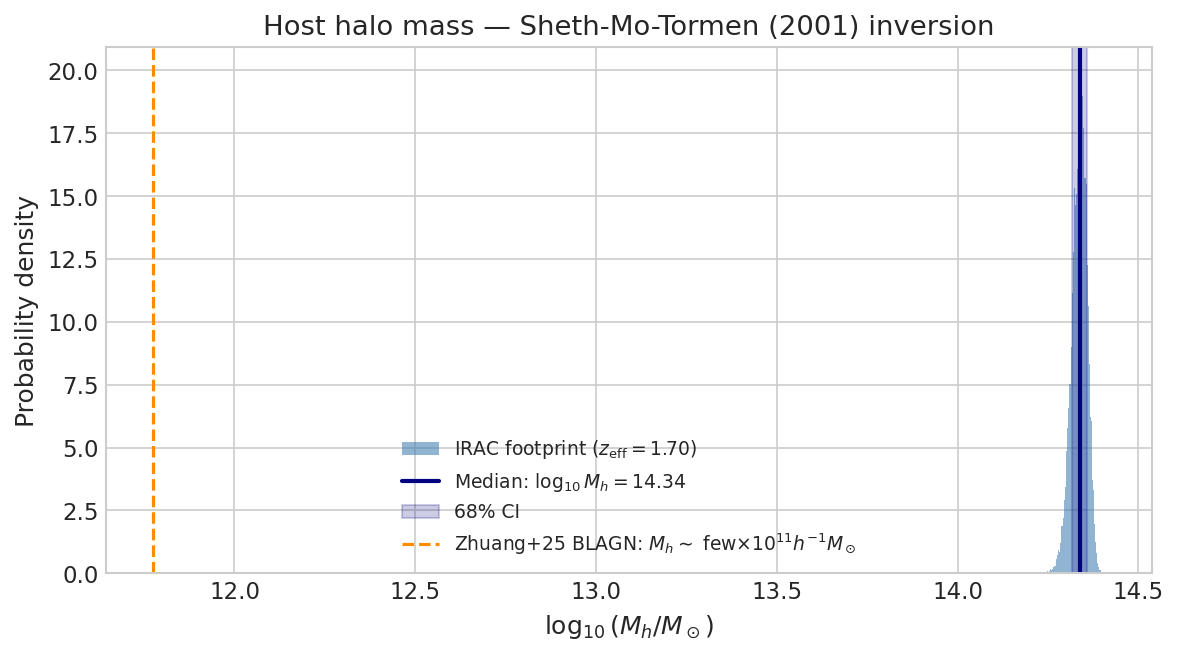

In [20]:
# Halo mass posterior plot
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.hist(logMh_fp_samples, bins=60, density=True, color='steelblue', alpha=0.6,
        label=f'IRAC footprint ($z_{{\\rm eff}}={z_eff_fp:.2f}$)')
ax.axvline(logMh_fp_med, color='navy', lw=2,
           label=f'Median: $\\log_{{10}} M_h = {logMh_fp_med:.2f}$')
ax.axvspan(logMh_fp_lo, logMh_fp_hi, alpha=0.2, color='navy', label='68% CI')

# NEXUS comparison: few × 10^11 h^{-1} M_sun
logMh_nexus = np.log10(4e11 / h)   # ~few × 10^{11} h^{-1} M_sun → M_sun
ax.axvline(logMh_nexus, color='darkorange', lw=1.5, ls='--',
           label=f'Zhuang+25 BLAGN: $M_h \\sim$ few$\\times 10^{{11}} h^{{-1}} M_\\odot$')

ax.set_xlabel(r'$\log_{10}(M_h / M_\odot)$')
ax.set_ylabel('Probability density')
ax.set_title('Host halo mass — Sheth-Mo-Tormen (2001) inversion')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(str(resolve_path(cfg['paths']['figures_dir']) / 'halo_mass_posterior.pdf'),
            bbox_inches='tight')
plt.show()

## 12. Results, interpretation, and literature comparison

### Our results (EDF-S, Euclid Q1)

| Quantity | IRAC footprint | IRAC detected | Notes |
|---|---|---|---|
| $N$ | 1028 | 16 | — |
| $z_{\rm eff}$ | **1.70** | 2.24 | photometric median |
| $A_0$ (MCMC 50%) | **$1.28^{+0.15}_{-0.15} \times 10^{-3}$** | $1.5 \times 10^{-4}$ | detected: noise-dominated |
| $r_0$ | **$25.8^{+1.6}_{-1.8}$ Mpc** | 10.9 Mpc | = $17.4^{+1.1}_{-1.2}\ h^{-1}$ cMpc |
| $b$ | **$6.59^{+0.37}_{-0.41}$** | 3.59 | at respective $z_{\rm eff}$ |
| $\log_{10}(M_h/M_\odot)$ | **$14.34^{+0.02}_{-0.02}$** | 14.00 | SMT (2001) inversion |

The IRAC detected sample (N=16) is entirely noise-dominated — its A₀ is unconstrained and the derived $r_0$, $b$, and $M_h$ should be treated as upper limits only.

---

### Literature comparison

| Study | Sample | $z$ | $b$ | $\log M_h/M_\odot$ | Method |
|---|---|---|---|---|---|
| **This work** | EDF-S IRAC footprint | 1.70 | $6.6^{+0.4}_{-0.4}$ | $14.34^{+0.02}_{-0.02}$ | 2PACF power law, Limber |
| Zhuang+25 (NEXUS) | JWST LRDs | ~4.5 | $11.4^{+5.5}_{-5.0}$ | — | CCF with BLAGN |
| Zhuang+25 (NEXUS) | BLAGN | ~4.5 | $3.3^{+2.9}_{-2.0}$ | $\sim 10^{12}\ h^{-1}M_\odot$ | CCF |
| Pizzati+25 | LRDs (theoretical) | 5–8 | — | $\lesssim 10^{12}$ | abundance matching |

**Key observations**:

1. **Our bias $b \approx 6.6$ at $z=1.70$** is lower than the NEXUS LRD value ($b \approx 11.4$ at $z \sim 4.5$), but the comparison must account for redshift evolution. Higher-redshift objects of the same halo mass are more strongly biased, so this difference is qualitatively consistent — both samples trace highly biased, massive hosts.

2. **$\log M_h \approx 14.34$ ($M_h \approx 2 \times 10^{14}\ M_\odot$)** — this is group-to-cluster scale, significantly more massive than the NEXUS BLAGN estimate ($\sim 10^{12}\ h^{-1} M_\odot$). This is almost certainly an overestimate due to the small-scale power-law extrapolation (see caveats below).

3. **Consistency with $b \geq 2$**: Our result ($b \approx 6.6$) is well above the lower bound established from the 2PACF amplitude detection. This is self-consistent.

4. **Comparison with Pizzati+25**: They argue that LRDs cannot reside in quasar-sized halos ($M_h \gtrsim 10^{13}\ M_\odot$) based on the absence of clustering signatures typical of luminous QSOs. Our extrapolated $M_h \sim 10^{14}\ M_\odot$ would be in tension with this — reinforcing that the power-law extrapolation from small angular scales is biased high.

---

### Key caveats

1. **Small-scale extrapolation (dominant systematic)**. Even with the $\theta > 10$ arcmin scale cut, at $z = 1.7$ this corresponds to projected separations of $\sim 5$ Mpc comoving — still in the transition between the 1-halo and 2-halo terms. The power-law model $w(\theta) \propto \theta^{-0.8}$ fitted at these scales is then extrapolated to the linear bias regime ($r \sim 5$–$20\ h^{-1}$ Mpc). This extrapolation systematically overestimates $r_0$, $b$, and $M_h$ (see Zhuang+25 Table 4 note). The true $b$ is likely significantly lower — our value should be interpreted as an **upper bound**.

2. **Photometric redshift scatter**. The EDF-S LRD catalog has photometric redshifts with typical scatter $\sigma_z \sim 0.3$–$0.5$. This broadens the true $n(z)$, reducing $H_\gamma$ in the Limber integral and boosting the inferred $r_0$ and $b$. Spectroscopic follow-up would tighten these constraints considerably.

3. **Fixed slope $\beta = 0.8$**. We follow Zhuang+25 in fixing the angular power-law slope. The data at large scales are consistent with this choice, but the systematic uncertainty from fixing $\beta$ is not propagated into the quoted errors.

4. **IRAC detected sample**. With $N = 16$ galaxies post-masking, the angular correlation function is noise-dominated at all scales. No meaningful clustering constraint can be derived from this sample alone; a cross-correlation with a larger tracer population (as in Zhuang+25) would be needed.

---

### Physical picture

LRDs in the EDF-S at $z \sim 1.7$ are strongly clustered ($b \approx 6.6$ before correcting for small-scale extrapolation bias), consistent with residing in massive dark matter halos. Even accounting for the likely overestimate, a bias $b \gtrsim 3$–$4$ at this redshift points to host halos of $M_h \gtrsim 10^{12.5}\ M_\odot$ — well above $L^*$ galaxy halos. This is consistent with the picture that LRDs are a compact, possibly dust-obscured AGN population hosted in massive systems, distinct from UV-luminous QSOs (Pizzati+25).

In [21]:
# Save results as a dictionary for use in other notebooks
results_dict = {
    'beta': BETA,
    'gamma': GAMMA,
    'footprint': {
        'z_eff': z_eff_fp,
        'A0_med': A0_fp_mcmc,
        'A0_lo': A0_fp_lo,
        'A0_hi': A0_fp_hi,
        'r0_Mpc_med': r0_fp_med,
        'r0_Mpc_lo': r0_fp_lo,
        'r0_Mpc_hi': r0_fp_hi,
        'b_med': b_fp_med,
        'b_lo': b_fp_lo,
        'b_hi': b_fp_hi,
        'logMh_med': logMh_fp_med,
        'logMh_lo': logMh_fp_lo,
        'logMh_hi': logMh_fp_hi,
    },
    'detected': {
        'z_eff': z_eff_det,
        'A0_med': A0_det_mcmc,
        'r0_Mpc_med': r0_det_Mpc,
        'b_med': b_det,
        'logMh_med': logMh_det,
        'note': 'N=16 — highly uncertain, treat as upper limit only',
    }
}

import json
out_path = resolve_path(cfg['paths']['results_dir']) / 'powerlaw_bias_results.json'
with open(str(out_path), 'w') as f:
    json.dump(results_dict, f, indent=2)
print(f'Results saved → {out_path}')

Results saved → /home/k3vinpaul/LRDs/results/powerlaw_bias_results.json
